# Synthetic Rx Rebate Data — Exploration

This notebook walks through the synthetic pharmaceutical rebate dataset:
- **Claims**: 500K prescription fills across retail, mail, and specialty channels
- **Drugs**: 300 NDC records with specialty classification
- **Formulary**: Tier placement and utilization management flags per client
- **Contracts**: Rebate agreements with 4 basis types
- **Invoices**: Quarterly rebate invoices with ±5% noise (normal) and injected anomalies

The data is generated by `src/synthetic_data_gen/` and saved to `data/synthetic/*.parquet`.

**Purpose**: Understand distributions before building anomaly detection models.

## 1. Setup & Data Load

In [9]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set seaborn style
sns.set_theme(style="whitegrid", palette="husl")

In [10]:
# Point to the synthetic data directory
# Adjust this path if running the notebook from a different working directory
data_dir = Path("../data/synthetic")

claims    = pl.read_parquet(data_dir / "claims.parquet")
drugs     = pl.read_parquet(data_dir / "drugs.parquet")
formulary = pl.read_parquet(data_dir / "formulary.parquet")
contracts = pl.read_parquet(data_dir / "contracts.parquet")
invoices  = pl.read_parquet(data_dir / "invoices_with_anomalies.parquet")

print("Data loaded successfully.")

Data loaded successfully.


## 2. Dataset Overview

In [11]:
# Row counts across all tables
print(f"Claims    : {len(claims):>10,}  (individual prescription fills)")
print(f"Drugs     : {len(drugs):>10,}  (unique NDC-11 records)")
print(f"Formulary : {len(formulary):>10,}  (NDC × client tier assignments)")
print(f"Contracts : {len(contracts):>10,}  (rebate agreements)")
print(f"Invoices  : {len(invoices):>10,}  (quarterly rebate invoices)")
print()

# Key column snapshots
print("Claims columns :", claims.columns)
print("Invoices columns:", invoices.columns)

Claims    :    500,000  (individual prescription fills)
Drugs     :        300  (unique NDC-11 records)
Formulary :     10,500  (NDC × client tier assignments)
Contracts :     10,870  (rebate agreements)
Invoices  :    118,124  (quarterly rebate invoices)

Claims columns : ['claim_id', 'member_id', 'group_id', 'ndc11', 'fill_date', 'days_supply', 'quantity', 'channel', 'plan_paid', 'gross_drug_cost', 'claim_status']
Invoices columns: ['invoice_quarter', 'manufacturer', 'ndc11', 'client_id', 'invoiced_utilization', 'expected_rebate', 'actual_rebate', 'disputed_rebate', 'paid_rebate', 'channel', 'brand_family']


## 3. Claims: Dispensing Channel Distribution

Three channels exist in this dataset:
- **Retail** (~70%): traditional pharmacy fills
- **Mail** (~20%): 90-day mail-order supplies
- **Specialty** (~10%): high-cost injectable / biologic therapies

Channel matters for rebate contracts because some manufacturers exclude certain channels.

shape: (3, 3)
┌───────────┬────────┬──────┐
│ channel   ┆ count  ┆ pct  │
│ ---       ┆ ---    ┆ ---  │
│ str       ┆ u32    ┆ f64  │
╞═══════════╪════════╪══════╡
│ retail    ┆ 350602 ┆ 70.1 │
│ mail      ┆ 99796  ┆ 20.0 │
│ specialty ┆ 49602  ┆ 9.9  │
└───────────┴────────┴──────┘


/var/folders/g7/822123tx4gn6ndvw2jgh5f140000gn/T/ipykernel_31962/428954617.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, y="channel", x="count", ax=ax, palette="Set2")


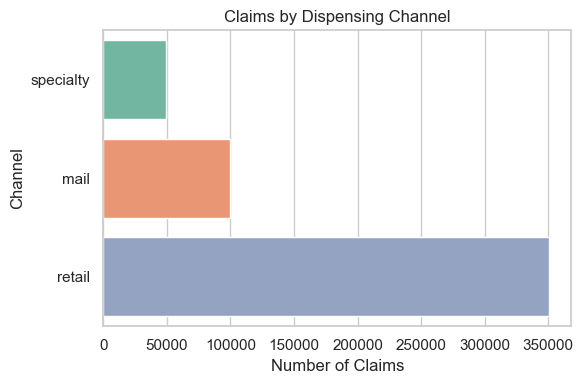

In [12]:
channel_counts = (
    claims
    .group_by("channel")
    .agg(pl.len().alias("count"))
    .with_columns(
        (pl.col("count") / pl.col("count").sum() * 100).round(1).alias("pct")
    )
    .sort("count", descending=True)
)

print(channel_counts)

# Plot with seaborn
fig, ax = plt.subplots(figsize=(6, 4))
data = channel_counts.to_pandas().sort_values("count", ascending=True)
sns.barplot(data=data, y="channel", x="count", ax=ax, palette="Set2")
ax.set_title("Claims by Dispensing Channel")
ax.set_xlabel("Number of Claims")
ax.set_ylabel("Channel")
plt.tight_layout()
plt.show()

shape: (4, 3)
┌─────────────┬────────┬──────┐
│ days_supply ┆ count  ┆ pct  │
│ ---         ┆ ---    ┆ ---  │
│ i64         ┆ u32    ┆ f64  │
╞═════════════╪════════╪══════╡
│ 30          ┆ 285097 ┆ 57.0 │
│ 60          ┆ 27525  ┆ 5.5  │
│ 84          ┆ 57478  ┆ 11.5 │
│ 90          ┆ 129900 ┆ 26.0 │
└─────────────┴────────┴──────┘


/var/folders/g7/822123tx4gn6ndvw2jgh5f140000gn/T/ipykernel_31962/2819271659.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x="days_supply", y="count", ax=ax, palette="Set2")


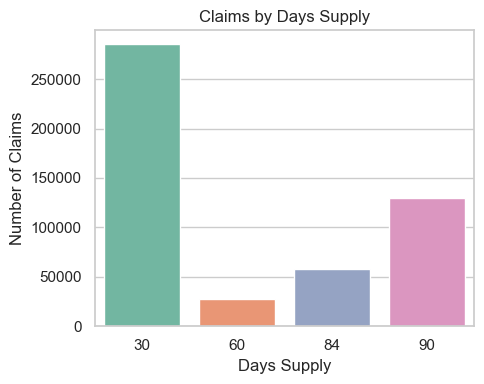

In [13]:
days_counts = (
    claims
    .group_by("days_supply")
    .agg(pl.len().alias("count"))
    .with_columns(
        (pl.col("count") / pl.col("count").sum() * 100).round(1).alias("pct")
    )
    .sort("days_supply")
)

print(days_counts)

# Plot with seaborn
fig, ax = plt.subplots(figsize=(5, 4))
data = days_counts.to_pandas()
sns.barplot(data=data, x="days_supply", y="count", ax=ax, palette="Set2")
ax.set_title("Claims by Days Supply")
ax.set_xlabel("Days Supply")
ax.set_ylabel("Number of Claims")
plt.tight_layout()
plt.show()

shape: (3, 6)
┌───────────┬─────────────┬─────────┬─────────┬─────────┬──────────┐
│ channel   ┆ mean        ┆ median  ┆ p25     ┆ p75     ┆ max      │
│ ---       ┆ ---         ┆ ---     ┆ ---     ┆ ---     ┆ ---      │
│ str       ┆ f64         ┆ f64     ┆ f64     ┆ f64     ┆ f64      │
╞═══════════╪═════════════╪═════════╪═════════╪═════════╪══════════╡
│ specialty ┆ 4123.499833 ┆ 1956.36 ┆ 1064.76 ┆ 3565.55 ┆ 95847.75 │
│ mail      ┆ 306.380353  ┆ 145.83  ┆ 79.54   ┆ 266.34  ┆ 7422.62  │
│ retail    ┆ 128.764895  ┆ 61.01   ┆ 33.22   ┆ 111.51  ┆ 3795.85  │
└───────────┴─────────────┴─────────┴─────────┴─────────┴──────────┘


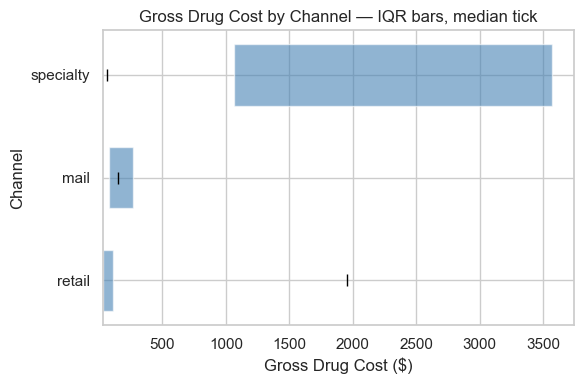

In [14]:
cost_stats = (
    claims
    .group_by("channel")
    .agg([
        pl.col("gross_drug_cost").mean().alias("mean"),
        pl.col("gross_drug_cost").median().alias("median"),
        pl.col("gross_drug_cost").quantile(0.25).alias("p25"),
        pl.col("gross_drug_cost").quantile(0.75).alias("p75"),
        pl.col("gross_drug_cost").max().alias("max"),
    ])
    .sort("mean", descending=True)
)
print(cost_stats)

# Plot with matplotlib - box plot style
fig, ax = plt.subplots(figsize=(6, 4))
data = cost_stats.to_pandas().sort_values("median")

# Create bar plot for IQR
for idx, row in data.iterrows():
    ax.barh(row['channel'], row['p75'] - row['p25'], 
            left=row['p25'], height=0.6, alpha=0.6, color='steelblue')
    # Add median line
    ax.plot(row['median'], idx, 'k-', linewidth=2, markersize=8, marker='|')

ax.set_xlabel("Gross Drug Cost ($)")
ax.set_ylabel("Channel")
ax.set_title("Gross Drug Cost by Channel — IQR bars, median tick")
plt.tight_layout()
plt.show()

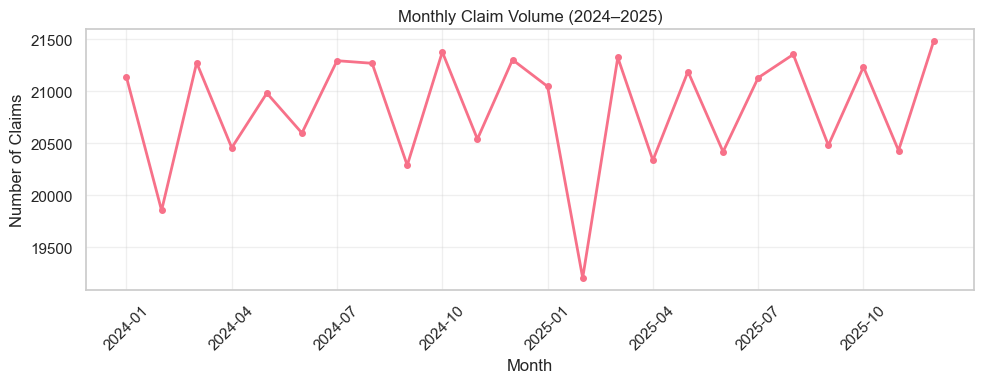

In [15]:
monthly = (
    claims
    .with_columns(
        pl.col("fill_date").dt.strftime("%Y-%m").alias("month")
    )
    .group_by("month")
    .agg(pl.len().alias("claims"))
    .sort("month")
)

# Plot with matplotlib
fig, ax = plt.subplots(figsize=(10, 4))
data = monthly.to_pandas()
ax.plot(range(len(data)), data['claims'], marker='o', linewidth=2, markersize=4)
ax.set_xticks(range(0, len(data), 3))
ax.set_xticklabels(data['month'].iloc[::3], rotation=45)
ax.set_xlabel("Month")
ax.set_ylabel("Number of Claims")
ax.set_title("Monthly Claim Volume (2024–2025)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

shape: (2, 4)
┌────────────────┬───────┬───────┬──────┐
│ specialty_flag ┆ count ┆ label ┆ pct  │
│ ---            ┆ ---   ┆ ---   ┆ ---  │
│ bool           ┆ u32   ┆ str   ┆ f64  │
╞════════════════╪═══════╪═══════╪══════╡
│ false          ┆ 210   ┆ false ┆ 70.0 │
│ true           ┆ 90    ┆ true  ┆ 30.0 │
└────────────────┴───────┴───────┴──────┘


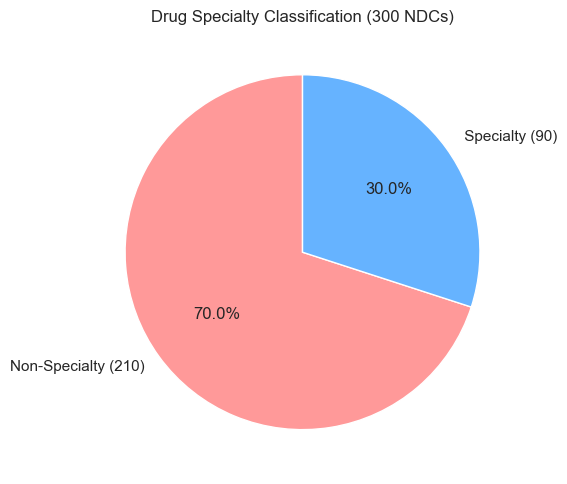

In [16]:
spec_counts = (
    drugs
    .group_by("specialty_flag")
    .agg(pl.len().alias("count"))
    .with_columns(
        pl.col("specialty_flag").cast(pl.Utf8).alias("label"),
        (pl.col("count") / pl.col("count").sum() * 100).round(1).alias("pct"),
    )
)
print(spec_counts)

# Plot pie chart with matplotlib
fig, ax = plt.subplots(figsize=(6, 5))
data = spec_counts.to_pandas()
labels = [f"{' Specialty' if str(x) == 'true' else 'Non-Specialty'} ({c})" 
          for x, c in zip(data['label'], data['count'])]
colors = ['#ff9999', '#66b3ff']
ax.pie(data['count'], labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax.set_title("Drug Specialty Classification (300 NDCs)")
plt.tight_layout()
plt.show()

shape: (6, 3)
┌──────┬───────┬──────┐
│ tier ┆ count ┆ pct  │
│ ---  ┆ ---   ┆ ---  │
│ i64  ┆ u32   ┆ f64  │
╞══════╪═══════╪══════╡
│ 1    ┆ 998   ┆ 9.5  │
│ 2    ┆ 2128  ┆ 20.3 │
│ 3    ┆ 3667  ┆ 34.9 │
│ 4    ┆ 2177  ┆ 20.7 │
│ 5    ┆ 1008  ┆ 9.6  │
│ 6    ┆ 522   ┆ 5.0  │
└──────┴───────┴──────┘


/var/folders/g7/822123tx4gn6ndvw2jgh5f140000gn/T/ipykernel_31962/2206230824.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tier_pd, x="tier_label", y="count", ax=ax, palette="Blues")


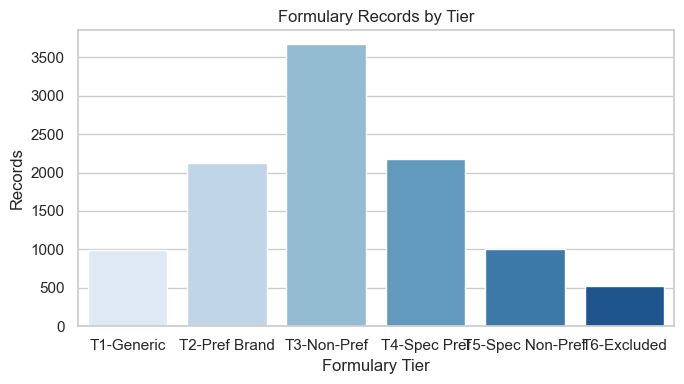

In [17]:
tier_counts = (
    formulary
    .group_by("tier")
    .agg(pl.len().alias("count"))
    .sort("tier")
    .with_columns(
        (pl.col("count") / pl.col("count").sum() * 100).round(1).alias("pct")
    )
)
print(tier_counts)

tier_labels = {1: "T1-Generic", 2: "T2-Pref Brand", 3: "T3-Non-Pref",
               4: "T4-Spec Pref", 5: "T5-Spec Non-Pref", 6: "T6-Excluded"}

tier_pd = tier_counts.to_pandas()
tier_pd["tier_label"] = tier_pd["tier"].map(tier_labels)

# Plot with seaborn
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=tier_pd, x="tier_label", y="count", ax=ax, palette="Blues")
ax.set_title("Formulary Records by Tier")
ax.set_xlabel("Formulary Tier")
ax.set_ylabel("Records")
plt.tight_layout()
plt.show()

shape: (4, 3)
┌────────────────────┬───────┬──────┐
│ rebate_basis       ┆ count ┆ pct  │
│ ---                ┆ ---   ┆ ---  │
│ str                ┆ u32   ┆ f64  │
╞════════════════════╪═══════╪══════╡
│ PER_30_DAY_SCRIPT  ┆ 4017  ┆ 37.0 │
│ PERCENT_GROSS_COST ┆ 3671  ┆ 33.8 │
│ PER_UNIT           ┆ 2241  ┆ 20.6 │
│ PMPM_GUARANTEE     ┆ 941   ┆ 8.7  │
└────────────────────┴───────┴──────┘


/var/folders/g7/822123tx4gn6ndvw2jgh5f140000gn/T/ipykernel_31962/3127073352.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, y="rebate_basis", x="count", ax=ax, palette="Set2")


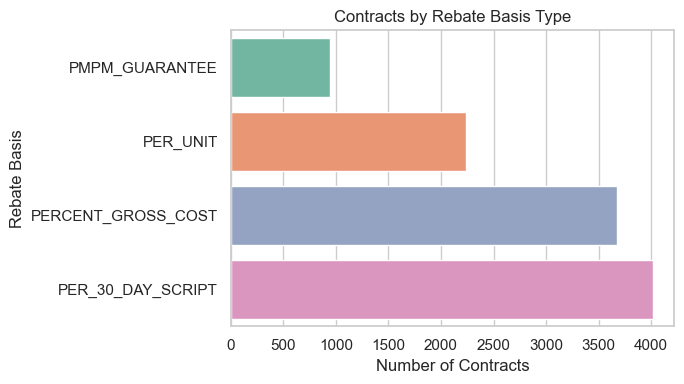

In [18]:
basis_counts = (
    contracts
    .group_by("rebate_basis")
    .agg(pl.len().alias("count"))
    .with_columns(
        (pl.col("count") / pl.col("count").sum() * 100).round(1).alias("pct")
    )
    .sort("count", descending=True)
)
print(basis_counts)

# Plot with seaborn
fig, ax = plt.subplots(figsize=(7, 4))
data = basis_counts.to_pandas().sort_values("count", ascending=True)
sns.barplot(data=data, y="rebate_basis", x="count", ax=ax, palette="Set2")
ax.set_title("Contracts by Rebate Basis Type")
ax.set_xlabel("Number of Contracts")
ax.set_ylabel("Rebate Basis")
plt.tight_layout()
plt.show()

Rows with expected_rebate > 0 : 73,337

Realization distribution:
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 73337.0  │
│ null_count ┆ 0.0      │
│ mean       ┆ 0.999965 │
│ std        ┆ 0.029666 │
│ min        ┆ 0.0      │
│ 25%        ┆ 0.975053 │
│ 50%        ┆ 1.0      │
│ 75%        ┆ 1.024943 │
│ max        ┆ 1.059701 │
└────────────┴──────────┘


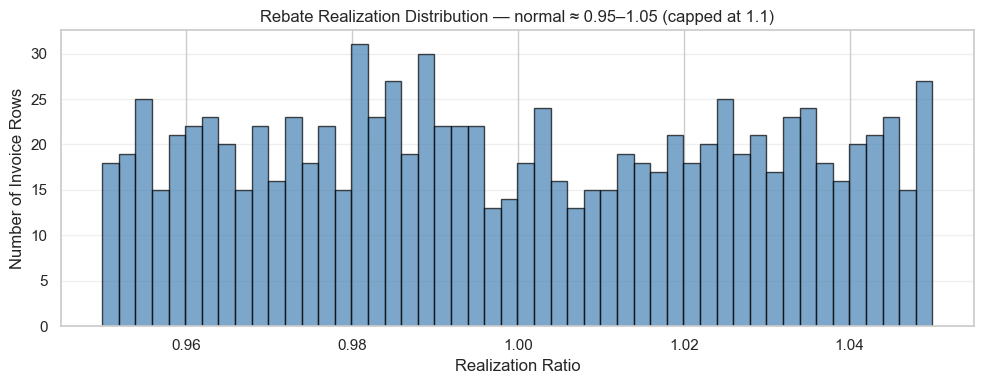

In [19]:
# Only rows where expected_rebate is positive
inv_nonzero = invoices.filter(pl.col("expected_rebate") > 0)

realization = inv_nonzero.with_columns(
    (pl.col("actual_rebate") / pl.col("expected_rebate")).alias("realization")
)

print(f"Rows with expected_rebate > 0 : {len(inv_nonzero):,}")
print()
print("Realization distribution:")
print(realization["realization"].describe())

# Clamp to [0, 1.1] for visualization clarity
hist_data = realization.with_columns(
    pl.col("realization").clip(0.0, 1.1)
).to_pandas()

# Plot histogram with matplotlib
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(hist_data["realization"].sample(min(1000, len(hist_data))), 
        bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel("Realization Ratio")
ax.set_ylabel("Number of Invoice Rows")
ax.set_title("Rebate Realization Distribution — normal ≈ 0.95–1.05 (capped at 1.1)")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Top 20 products by total expected rebate:
shape: (20, 2)
┌───────────────────┬───────────────────────┐
│ product           ┆ total_expected_rebate │
│ ---               ┆ ---                   │
│ str               ┆ f64                   │
╞═══════════════════╪═══════════════════════╡
│ 10000000032 / M01 ┆ 2.1310e6              │
│ 10000000083 / M16 ┆ 1.5626e6              │
│ 10000000086 / M01 ┆ 1.3367e6              │
│ 10000000133 / M11 ┆ 1.1537e6              │
│ 10000000130 / M11 ┆ 1.1413e6              │
│ …                 ┆ …                     │
│ 10000000062 / M07 ┆ 790091.55             │
│ 10000000274 / M08 ┆ 713810.82             │
│ 10000000097 / M13 ┆ 695420.8              │
│ 10000000175 / M09 ┆ 653472.22             │
│ 10000000247 / M08 ┆ 645829.08             │
└───────────────────┴───────────────────────┘


OverflowError: signed integer is greater than maximum

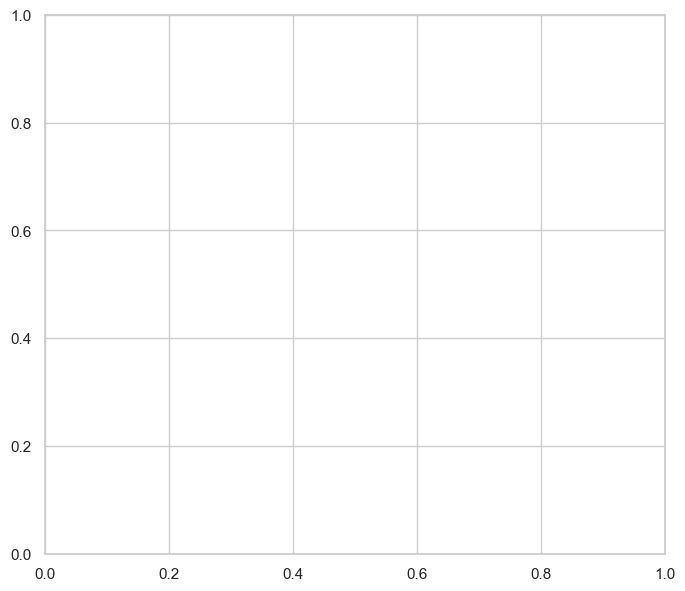

In [20]:
top_products = (
    invoices
    .group_by(["ndc11", "manufacturer"])
    .agg(pl.col("expected_rebate").sum().alias("total_expected_rebate"))
    .sort("total_expected_rebate", descending=True)
    .head(20)
    .with_columns(
        (pl.col("ndc11") + " / " + pl.col("manufacturer")).alias("product")
    )
)

print("Top 20 products by total expected rebate:")
print(top_products[["product", "total_expected_rebate"]])

# Plot with seaborn
fig, ax = plt.subplots(figsize=(8, 7))
data = top_products.to_pandas().sort_values("total_expected_rebate")
sns.barplot(data=data, y="product", x="total_expected_rebate", ax=ax, palette="viridis")
ax.set_title("Top 20 Products by Expected Rebate")
ax.set_xlabel("Total Expected Rebate ($)")
ax.set_ylabel("NDC / Manufacturer")
plt.tight_layout()
plt.show()

In [ ]:
drug_ndcs = set(drugs["ndc11"].to_list())

# MISSING_REBATE: expected > 0, actual = 0, NDC exists in drug master
missing_rebate = invoices.filter(
    (pl.col("expected_rebate") > 0)
    & (pl.col("actual_rebate") == 0)
    & pl.col("ndc11").is_in(list(drug_ndcs))
)

# UNMAPPED_NDC: NDC does not exist in the drug master
unmapped_ndc = invoices.filter(
    ~pl.col("ndc11").is_in(list(drug_ndcs))
    & (pl.col("expected_rebate") > 0)
)

# REBATE_YIELD_COLLAPSE: realization < 50% with non-trivial expected rebate
yield_collapse = invoices.filter(
    (pl.col("expected_rebate") > 10)
    & (pl.col("actual_rebate") > 0)
    & ((pl.col("actual_rebate") / pl.col("expected_rebate")) < 0.50)
)

# DISPUTE_SPIKE: rows where disputed_rebate > 0
dispute_brands = (
    invoices
    .filter(pl.col("disputed_rebate") > 0)
    .group_by(["manufacturer", "brand_family", "invoice_quarter"])
    .agg(pl.col("disputed_rebate").sum().alias("total_disputed"))
    .sort("total_disputed", descending=True)
)

print("=== Detected Anomaly Patterns ===")
print(f"MISSING_REBATE rows         : {len(missing_rebate)}")
print(f"UNMAPPED_NDC rows           : {len(unmapped_ndc)}")
print(f"REBATE_YIELD_COLLAPSE rows  : {len(yield_collapse)}")
print(f"DISPUTE_SPIKE brand-quarters: {len(dispute_brands)}")
print()
print("Missing rebate detail:")
print(missing_rebate[["invoice_quarter", "ndc11", "client_id", "expected_rebate"]])
print()
print("Dispute spike summary:")
print(dispute_brands)

## 13. Referential Integrity Check

Before training models, verify that keys are consistent across tables.  
Foreign-key violations would indicate data quality issues (or intentional unmapped-NDC anomalies).

In [ ]:
claim_ndcs   = set(claims["ndc11"].to_list())
invoice_ndcs = set(invoices["ndc11"].to_list())

# Check 1: All claim NDCs exist in drug master
orphan_claim_ndcs = claim_ndcs - drug_ndcs
status_1 = "PASS" if not orphan_claim_ndcs else f"FAIL — {len(orphan_claim_ndcs)} orphan NDCs"
print(f"Claim NDCs in drug master     : {status_1}")

# Check 2: Invoice NDCs either in drug master OR are injected unmapped NDCs
orphan_invoice_ndcs = invoice_ndcs - drug_ndcs
status_2 = (
    "PASS (expected — these are injected UNMAPPED_NDC anomalies)"
    if orphan_invoice_ndcs
    else "PASS"
)
print(f"Invoice NDCs not in drug master: {len(orphan_invoice_ndcs)} → {status_2}")
if orphan_invoice_ndcs:
    print(f"  Unmapped NDCs: {orphan_invoice_ndcs}")

# Check 3: Formulary NDCs in drug master
formulary_ndcs = set(formulary["ndc11"].to_list())
orphan_formulary = formulary_ndcs - drug_ndcs
status_3 = "PASS" if not orphan_formulary else f"FAIL — {len(orphan_formulary)} orphan NDCs"
print(f"Formulary NDCs in drug master : {status_3}")

# Check 4: Invoice quarters are well-formed
malformed_quarters = invoices.filter(
    ~pl.col("invoice_quarter").str.contains(r"^\d{4}-Q[1-4]$")
)
status_4 = "PASS" if len(malformed_quarters) == 0 else f"FAIL — {len(malformed_quarters)} rows"
print(f"Invoice quarter format        : {status_4}")

## 14. Summary

This notebook explored the full synthetic rebate dataset.  
Key takeaways for anomaly detection:

In [ ]:
total_expected = invoices["expected_rebate"].sum()
total_actual   = invoices["actual_rebate"].sum()
rebate_gap     = total_expected - total_actual

print("""
=== Synthetic Dataset Overview ===

Tables & Rows
  Claims    : 500,000  (2024-01-01 – 2025-12-31, 3 channels)
  Drugs     :     300  (30% specialty / 70% non-specialty)
  Formulary :  10,500  (6 tiers, PA/ST/QL flags)
  Contracts :  10,870  (4 rebate basis types)
  Invoices  : 118,124  (8 quarters × NDC × client, with anomalies)

Normal Behavior
  Rebate realization (actual/expected) peaks at 1.0 ± 5% noise
  Specialty drugs are ~30x more expensive than retail
""")

print(f"Total expected rebate : ${total_expected:>15,.2f}")
print(f"Total actual rebate   : ${total_actual:>15,.2f}")
print(f"Overall rebate gap    : ${rebate_gap:>15,.2f}")
print()
print("""
Injected Anomalies (ground truth recovered from data)
  MISSING_REBATE        — expected > 0, actual = 0
  UNMAPPED_NDC          — NDC not in drug master
  REBATE_YIELD_COLLAPSE — realization < 50%
  DISPUTE_SPIKE         — disputed_rebate > 0

Next Step → notebooks/02_train_anomaly_models.ipynb
""")